# $$Digit-Recognition-Project$$

We have a trained model
- We will bring in a handwritten image
- we will use the model to run inference on it

1. Upload image into notebook
2. Load the model
3. Making an Inference ---> Pass image through the model - making a prediction

Libraries we could use:
- Python Imaging Library - PIL 
    - known as `Pillow`
    - used for image processing
    - open, resize, convert image formats
    - Open a .png and save it as .jpg or .webp
    - can convert an `RGB` color image to  `L` grayscale image
    - resize, rotate, crop
    - brightness, contrast, sharpness
- OpenCV - 

In [1]:
# 
import numpy as np
from PIL import Image, ImageOps

import tensorflow as tf

In [2]:
# load model
model = tf.keras.models.load_model('digit-recognition-model.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [24]:
path = 'five_img.jpg'

img = Image.open(path) # pil object

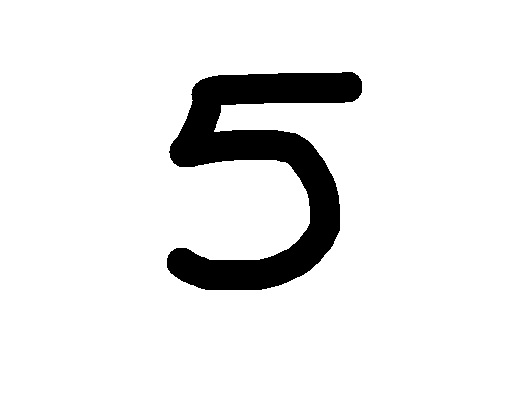

In [25]:
type(img)
img

- Neural Networks are very strict
- input should be of the exact shape, size, format, that the training data was
- otherwise bad predictions

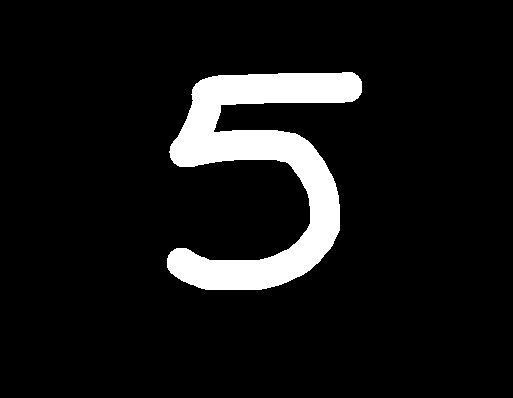

In [26]:
img = ImageOps.invert(img)
img

In [28]:
img = img.convert('L') # convert the image into Grayscale


In [29]:
# Resizing in PIL
img = img.resize((28,28))
img

In [12]:
# convert the PIL object into a numpy array
img_np = np.array(img)
img_np.shape # shape 28,28, 3     # 398, 513, 3

(28, 28)

In [13]:
# shape fix
img_np = img_np.reshape(1,28, 28, 1)

img_np.shape

(1, 28, 28, 1)

In [14]:
img_np = img_np / 255
# img_np

In [15]:
# tensorflow model accepts inputs of certain shape
# batch, height, width, channels
# (1, 28, 28, 1)

prediction = model.predict(img_np)
prediction

predicted_digit = np.argmax(prediction)

# please write the lines of code, to print the exact Predicted Digit here
print(f'The prediction is: {predicted_digit}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
The prediction is: 5


In [16]:
np.max((prediction).round(2)*100) # the maximum will also determine the confidence of the model

np.float32(72.0)

> Exercise:
- Create a function, that takes in an image path, and makes a prediction

In [ ]:
path = 'three_img.jpg'

def predict_digit(image_path = path):
    img = Image.open(image_path) # pil object
    img = img.convert('L') # convert the image into Grayscale

    img = ImageOps.invert(img) # invert the pixel values ---> white to black

    img = img.resize((28,28)) # Resizing in PIL

    img_np = np.array(img) # convert the PIL object into a numpy array
    img_np = img_np.reshape(1,28, 28, 1)

    img_np = img_np / 255 # scale the values

    prediction = model.predict(img_np)

    predicted_digit = np.argmax(prediction)

    confidence = np.max((prediction.round(2))*100)

    print(f"The predicted digit is: {predicted_digit} | Confidence: {confidence}")

    return predicted_digit, confidence

predict_digit(path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
The predicted digit is: 3 | Confidence: 100.0


(np.int64(3), np.float32(100.0))

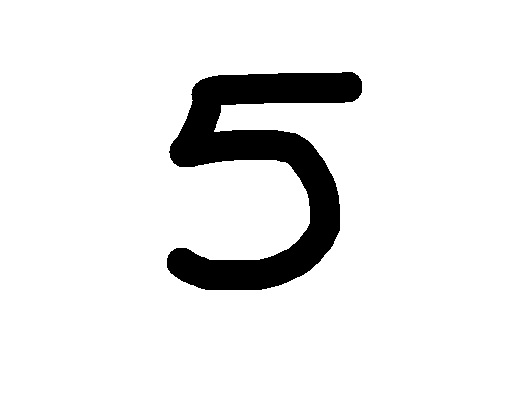

In [ ]:
path3 = 'src/three_img.jpg'
path4 = 'src/four_img.png'
path5 = 'src/five_img.jpg'

img = Image.open(path5)
img

In [33]:
predict_digit(path5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
The predicted digit is: 5 | Confidence: 99.0


(np.int64(5), np.float32(99.0))

## Handwritten Digit Recognition

In [ ]:
img_path = 'src/image.jpg'

digit = Image.open(img_path)
digit_np = np.array(digit)
digit_np.shape

(1600, 900, 3)

In [ ]:
img = Image.open(img_path)
# img = img.resize((200,200)) 

w, h = img.size # 1600, 900

incr = 200
img = img.crop(box=(0+incr, 350+incr, w-incr, w+350-incr)) # left, top, right, bottom

img.save('src/cropped_image.jpg')

In [ ]:
predict_digit(image_path='src/cropped_image.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
The predicted digit is: 7 | Confidence: 92.0


(np.int64(7), np.float32(92.0))

# **Live Digit Recognizer**
- We Draw, and the model makes inference



In [67]:
# pip install opencv-python

In [39]:
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import clear_output
from PIL import Image, ImageOps


import cv2
import tensorflow as tf

In [50]:
# load model
model = tf.keras.models.load_model('src/digit-recognition-model.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [40]:
def predict_digit(image_path = path):
    img = Image.open(image_path) # pil object
    img = img.convert('L') # convert the image into Grayscale
    # img = ImageOps.invert(img) # invert the pixel values ---> white to black
    img = img.resize((28,28)) # Resizing in PIL
    img_np = np.array(img) # convert the PIL object into a numpy array
    img_np = img_np.reshape(1,28, 28, 1)
    img_np = img_np / 255 # scale the values
    prediction = model.predict(img_np)
    predicted_digit = np.argmax(prediction)
    confidence = np.max((prediction.round(2))*100)
    print(f"The predicted digit is: {predicted_digit} | Confidence: {confidence}")


    clear_output(wait= True)

    plt.figure(figsize = (3,3))
    plt.imshow(img_np.reshape((28,28)), cmap= "gray")
    plt.title(f"Prediction: {predicted_digit} | Confidence: {confidence}")
    plt.axis("off")
    plt.show()

    return predicted_digit, confidence

- Building a canvas to draw on, using OpenCV

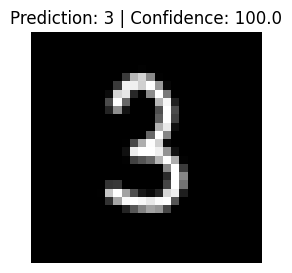

In [52]:
canvas = np.zeros((280, 280), dtype= np.uint8)

drawing = False

def draw(event, x, y, flags, param):
    global drawing, canvas

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True

    elif event == cv2.EVENT_MOUSEMOVE:
        if drawing:
            cv2.circle(canvas, (x,y), 8, (255), -1)

    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

cv2.namedWindow("Draw Digit")
cv2.setMouseCallback("Draw Digit", draw)

print("Instructions")
print("="*50)
print("Hold Left mouse button to draw")
print("Press c to clear")
print("Press v to save")
print("Press q to quit")
print("="*50)

while True: 
    cv2.imshow("Draw Digit", canvas)
    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('c'):
        canvas[:] = 0

    elif key == ord('v'):
        cv2.imwrite("src/digit.png", canvas)
        print('Image saved as digit.png')

        path = "src/digit.png"
        predict_digit(path)

cv2.destroyAllWindows()

- Treat this as you basics for any models you use after this
- 
- 